In [3]:
#%pip install pandas geopandas plotly scikit-learn numpy prophet
import pandas as pd
import geopandas as gpd
import plotly.express as px
import numpy as np
import sqlite3
from prophet import Prophet

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def load_and_transform_energy_data():
    # Read CSV with proper data types
    df = pd.read_csv('energy-and-utilities-linc.csv',
                     delimiter=';',
                     names=['County', 'Empty', 'Year', 'Variable', 'Value'],
                     dtype={'County': str, 'Empty': str, 'Year': str, 'Variable': str, 'Value': str})
    
    # Remove header rows and clean data
    df = df[~df['County'].isin(['Area Name', 'County'])]
    df = df[df['Value'].str.isnumeric().fillna(False)]

    # Drop empty column and convert types
    df = df.drop('Empty', axis=1)
    df['Value'] = pd.to_numeric(df['Value'])
    df['Year'] = pd.to_numeric(df['Year'])
    
    # Create pivot table
    transformed_df = pd.pivot_table(
        df,
        values='Value',
        index=['County', 'Year'],
        columns='Variable',
        aggfunc='first'
    ).reset_index()
    
    # Rename columns for clarity
    column_mapping = {
        'Occupied Housing Units Heated by Electricity': 'heated_by_electricity',
        'Occ Housing Units Heated by Gas Piped Underground': 'heated_by_gas',
        'Occupied Housing Units Heated by Fuel Oil': 'heated_by_fuel_oil',
        'Occ Housing Units Heated by Coal, Wood, Solar, or Other': 'heated_by_other',
        'Occupied Housing Units without House Heating Fuel': 'no_heating',
        'Occ Housing Units Heated by Bottled Tank or LP Gas Fuel': 'heated_by_lp_gas'
    }
    
    # Convert types and fill nulls
    transformed_df = transformed_df.rename(columns=column_mapping)
    transformed_df = transformed_df.fillna(0)
    
     # Convert to integers after cleaning
    numeric_cols = transformed_df.columns.difference(['County'])
    transformed_df[numeric_cols] = transformed_df[numeric_cols].astype(int)
    

    return transformed_df

# Cell 4: Create SQLite Database
def create_database():
    # Get transformed data
    energy_df = load_and_transform_energy_data()
    
    # Create database connection
    conn = sqlite3.connect('nc_energy.db')
    
    # Create table schema
    create_table_sql = '''
    CREATE TABLE IF NOT EXISTS energy_consumption (
        County TEXT,
        Year INTEGER,
        heated_by_electricity INTEGER,
        heated_by_gas INTEGER,
        heated_by_fuel_oil INTEGER,
        heated_by_other INTEGER,
        no_heating INTEGER,
        heated_by_lp_gas INTEGER,
        PRIMARY KEY (County, Year)
    ) WITHOUT ROWID;
    '''
    conn.executescript(create_table_sql)
    energy_df.to_sql('energy_consumption', conn, if_exists='replace', index=False)
    # Insert data
    energy_df.to_sql('energy_consumption', 
                     conn, 
                     if_exists='replace', 
                     index=False,
                     dtype={
                         'County': 'TEXT',
                         'Year': 'INTEGER',
                         'heated_by_electricity': 'INTEGER',
                         'heated_by_gas': 'INTEGER',
                         'heated_by_fuel_oil': 'INTEGER',
                         'heated_by_other': 'INTEGER',
                         'no_heating': 'INTEGER',
                         'heated_by_lp_gas': 'INTEGER'
                     })
    
    return conn, energy_df

def get_county_data(conn, county_name):
    query = '''
    SELECT 
        County,
        Year,
        heated_by_electricity,
        heated_by_gas,
        heated_by_fuel_oil,
        heated_by_other,
        no_heating,
        heated_by_lp_gas
    FROM energy_consumption 
    WHERE County = ?
    ORDER BY Year;
    '''
    return pd.read_sql(query, conn, params=(county_name,))

# Create database with new structure
energy_df = load_and_transform_energy_data()
print(energy_df.head())
print("\nColumns:", energy_df.columns.tolist())
print("\nData types:", energy_df.dtypes)

#Test get_county_data
conn, energy_df = create_database()
county_data = get_county_data(conn, 'Guilford County')
print(county_data.head())


Variable           County  Year  heated_by_lp_gas  heated_by_other  \
0         Alamance County  1990              4006             2541   
1         Alamance County  2000              6511             1005   
2         Alamance County  2010              6194             1243   
3         Alamance County  2015              5119             1918   
4         Alamance County  2020              4005             1101   

Variable  heated_by_gas  heated_by_electricity  heated_by_fuel_oil  no_heating  
0                 15946                  12543                7552          64  
1                 24211                  16783                2996          78  
2                 26390                  23032                2086          55  
3                 26122                  26576                1578         232  
4                 26842                  32290                 848         369  

Columns: ['County', 'Year', 'heated_by_lp_gas', 'heated_by_other', 'heated_by_gas', 'heated_

In [5]:
# Cell 3: Load Geographic Data
def load_geo_data():
    """Load and process geographic data"""
    counties_gdf = pd.read_csv('NCCountyCoordinates.csv')
    return counties_gdf
    
counties_gdf = load_geo_data()

In [6]:
# Cell 4: Query Functions
#Specific County Data
def get_county_data(conn, county_name):
    query = '''
    SELECT * FROM energy_consumption 
    WHERE county = ? 
    ORDER BY Year
    '''
    return pd.read_sql_query(query, conn, params=[county_name])

#County List
def get_county_list(conn):
    query = '''
    SELECT DISTINCT county FROM energy_consumption
    '''
    return pd.read_sql_query(query, conn)

#Select largest counties
def get_largest_counties(conn, n=5):
    query = '''
    SELECT county, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY county
    ORDER BY total_energy DESC
    LIMIT ?
    '''
    return pd.read_sql_query(query, conn, params=[n])

#Select total energy by year
def get_total_energy_by_year(conn):
    query = '''
    SELECT year, SUM(heated_by_electricity + heated_by_gas + heated_by_fuel_oil + heated_by_other + no_heating + heated_by_lp_gas) as total_energy
    FROM energy_consumption
    GROUP BY year
    '''
    return pd.read_sql_query(query, conn)

#Print the returned queries
print(get_county_list(conn))
print(get_county_data(conn, 'Guilford County').head())

              County
0    Alamance County
1   Alexander County
2   Alleghany County
3       Anson County
4        Ashe County
..               ...
95      Wayne County
96     Wilkes County
97     Wilson County
98     Yadkin County
99     Yancey County

[100 rows x 1 columns]
            County  Year  heated_by_lp_gas  heated_by_other  heated_by_gas  \
0  Guilford County  1990              4291             5438          48770   
1  Guilford County  2000              7941             2034          76608   
2  Guilford County  2010              7944             1771          85699   
3  Guilford County  2015              6445             1999          82119   
4  Guilford County  2020              6132             1926          85206   

   heated_by_electricity  heated_by_fuel_oil  no_heating  
0                  57535               21482         190  
1                  71024               10715         345  
2                  87088                6580         479  
3                 1

In [7]:
#Cell 5: Plotting Trends

#Calculating and identifying growth patterns
def calculate_growth_patterns(df, heating_type):
    df = df.sort_values('Year')
    # Calculate year-over-year changes
    df['yearly_change'] = df[heating_type].diff()
    # Calculate percentage changes
    df['pct_change'] = df[heating_type].pct_change()
    # Calculate average growth rate
    df['avg_growth'] = df['pct_change'].rolling(window=2).mean()
    return df

#Training the model with historical patterns
def train_time_series_model(conn, county_name, heating_type):
    # Get historical data
    df = get_county_data(conn, county_name)
    df = calculate_growth_patterns(df, heating_type)
    
    # Calculate overall trend
    avg_growth_rate = df['pct_change'].mean()
    last_value = df[heating_type].iloc[-1]
    
    return df, avg_growth_rate, last_value

#Predicting with trends
def predict_with_trends(df, avg_growth_rate, last_value, county_name, heating_type):
    future_years = range(2025, 2041, 5)
    predictions = []
    current_value = last_value
    
    for year in future_years:
        # Apply growth rate to previous value
        current_value = current_value * (1 + avg_growth_rate)
        
        predictions.append({
            'County': county_name,
            'Year': year,
            heating_type: int(current_value)
        })
    
    return pd.DataFrame(predictions)

# Usage
county_name = 'Guilford County'
heating_type = 'heated_by_electricity'

# Train model and get predictions
historical_data, growth_rate, last_value = train_time_series_model(conn, county_name, heating_type)
predictions = predict_with_trends(historical_data, growth_rate, last_value, county_name, heating_type)

# Print results
print(f"\nHistorical Growth Rate: {growth_rate:.2%}")
print(f"\nPredictions for {county_name}:")
print(predictions)


Historical Growth Rate: 18.20%

Predictions for Guilford County:
            County  Year  heated_by_electricity
0  Guilford County  2025                 131869
1  Guilford County  2030                 155873
2  Guilford County  2035                 184245
3  Guilford County  2040                 217782


13:51:09 - cmdstanpy - INFO - Chain [1] start processing
13:51:14 - cmdstanpy - INFO - Chain [1] done processing
/var/folders/_1/zb6p0cnx2bzdgcq662_dmxx80000gn/T/ipykernel_13548/3342848807.py:29: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  'ds': pd.date_range(



Prophet Predictions for Guilford County:
            County  Year  heated_by_electricity
0  Guilford County  2025                 120094
1  Guilford County  2030                 127204
2  Guilford County  2035                 134314
3  Guilford County  2040                 141428

Historical Data for Guilford County:
   Year  heated_by_electricity
0  1990                  57535
1  2000                  71024
2  2010                  87088
3  2015                 104453
4  2020                 111563


NameError: name 'plt' is not defined

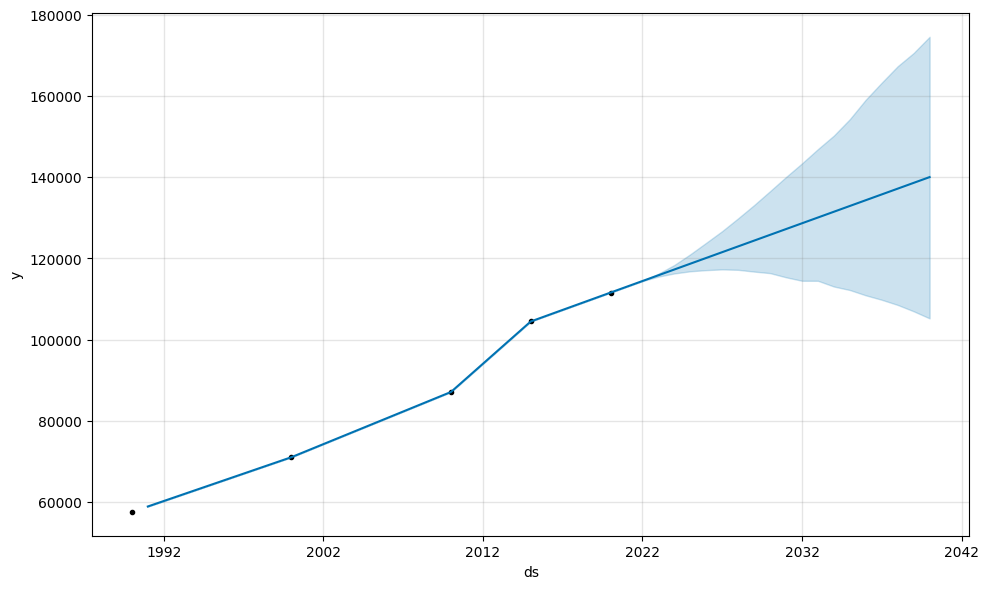

In [9]:
# Cell: ML Predictions with Prophet

def create_prophet_predictions(conn, county_name, heating_type):
    # Get historical data
    query = f"""
    SELECT Year, {heating_type}
    FROM energy_consumption 
    WHERE County = ?
    ORDER BY Year
    """
    df = pd.read_sql_query(query, conn, params=[county_name])
    
    # Prepare data for Prophet
    prophet_df = pd.DataFrame({
        'ds': pd.to_datetime(df['Year'].astype(str)),
        'y': df[heating_type]
    })
    
    # Create and train model
    model = Prophet(
        yearly_seasonality=False,
        growth='linear',
        changepoint_prior_scale=0.5
    )
    model.fit(prophet_df)
    
    # Create future dates
    future_dates = pd.DataFrame({
        'ds': pd.date_range(
            start='2025-01-01', 
            end='2041-01-01',
            freq='5Y'
        )
    })
    
    # Generate predictions
    forecast = model.predict(future_dates)
    
    # Create prediction DataFrame
    predictions = pd.DataFrame({
        'County': county_name,
        'Year': forecast['ds'].dt.year,
        heating_type: forecast['yhat'].astype(int)
    })
    
    return predictions, model

# Usage
county_name = 'Guilford County'
heating_type = 'heated_by_electricity'

# Generate predictions
predictions, model = create_prophet_predictions(conn, county_name, heating_type)

# Print results
print(f"\nProphet Predictions for {county_name}:")
print(predictions)

# Get historical data for comparison
historical = get_county_data(conn, county_name)
print(f"\nHistorical Data for {county_name}:")
print(historical[['Year', heating_type]])

# Plot results
fig = model.plot(model.predict(pd.DataFrame({
    'ds': pd.date_range(start='1990-01-01', end='2040-01-01', freq='YE')
})))
plt.show()

In [ ]:
def create_choropleth_map(conn, counties_gdf, heating_type, year):
    """Create interactive choropleth map of NC counties"""
    # Get data for specified year
    query = f"""
    SELECT County, {heating_type}
    FROM energy_consumption 
    WHERE Year = ?
    """
    df = pd.read_sql_query(query, conn, params=[year])
    
    # Convert GeoJSON to proper format
    counties_json = {
        "type": "FeatureCollection",
        "features": [
            {
                "type": "Feature",
                "properties": {"NAME": row["Area Name"]},
                "geometry": eval(row["geo_shape"])
            } for _, row in counties_gdf.iterrows()
        ]
    }

    # Create choropleth map
    fig = px.choropleth(
        df,
        geojson=counties_json,
        locations='County',
        featureidkey="properties.NAME",
        color=heating_type,
        scope="usa",
        title=f'NC {heating_type} by County ({year})',
        labels={heating_type: 'Number of Houses'},
        color_continuous_scale="Viridis"
    )

    # Update map view
    fig.update_geos(
        fitbounds="locations",
        visible=False,
        center={"lat": 35.5, "lon": -80},
        scope='usa',
    )
    
    # Add slider
    years = [1990, 2000, 2010, 2015, 2020, 2025, 2030, 2035, 2040]
    steps = []
    for year in years:
        if year <= 2020:
            # Historical data
            query = f"SELECT County, {heating_type} FROM energy_consumption WHERE Year = ?"
            year_data = pd.read_sql_query(query, conn, params=[year])
        else:
            # Predicted data
            year_data = predictions[predictions['Year'] == year]
        
        step = dict(
            method='update',
            args=[{'z': [year_data[heating_type]]},
                  {'title': f'NC {heating_type} by County ({year})'}],
            label=str(year)
        )
        steps.append(step)
    
    sliders = [dict(
        active=0,
        steps=steps
    )]
    
    fig.update_layout(sliders=sliders)
    
    return fig

# Usage example
heating_type = 'heated_by_electricity'
fig = create_choropleth_map(conn, counties_gdf, heating_type, 2020)
fig.write_html("nc_energy_map.html")  # Save as interactive HTML